<center><b>EE (P) 533 Spring 2026<br>
Analog Circuits for Sensor Systems<br>
University of Washington Electrical & Computer Engineering</b></center>

<b>Instructor: Mahmood Hameed<br>
Assignment #5 (10 points)<br>
Due Monday, May 11 (Submit on Canvas as a Jupyter Notebook)</b>

*Please show your work*

<b>Problem 1: Differential amplifier analysis and design

<center><img src="img/HW5_bridge_amplifier.png" width=800></center>
<br>
<center><b> Figure 1a. Wheatstone bridge amplifier</b></center>

<center><img src="img/HW5_inamp.png" width=600></center>
<br>
<center><b> Figure 1b. Instrumentation amplifier</b></center>

A difference amplifier can be used to amplify the signal from a Wheatstone bridge, but loading is a concern due to the finite input resistance of the amplifier. 

To determine the extent of loading, we need to quantify the output resistance of the bridge circuit and the input resistance of the amplifier.

<u>*Analysis/Design*</u>

__a)__ Determine expressions for the output resistance $R_{S}$ of the bridge circuit and the input resistance $R_{in}$ of the amplifier. Use the same approach you would use to determine the Thevenin resistance of a single-ended circuit (i.e. do not assume a balanced differential signal). Assume the opamp is ideal.

Assuming the Wheastone bridge resistance $R = 500 \Omega$, design the difference amplifier (i.e. determine values for $R_1$ and $R_2$) to provide a gain of $20dB$ with a maximum of $1\%$ input attenuation due to loading.

For the bridge output resistance, I turn off the 5 V source, so the top and bottom bridge nodes both become AC ground. Looking into the two bridge output nodes,

$$
R_S=\left(R\parallel (R+\Delta R)\right)+\left((R+\Delta R)\parallel R\right)
$$

so

$$
R_S=2\frac{R(R+\Delta R)}{2R+\Delta R}.
$$

At $\Delta R=0$, this becomes

$$
R_S=R=500\Omega.
$$

For the difference amplifier, I use a floating test source across the two input terminals. With the ideal op amp forcing $v_-=v_+$, the differential test current goes through two $R_1$ resistors, so

$$
R_{in}=2R_1.
$$

The gain requirement is

$$
20dB \Rightarrow A_v=10=\frac{R_2}{R_1}.
$$

For less than 1% loading,

$$
\frac{R_{in}}{R_S+R_{in}}\ge 0.99.
$$

With $R=500\Omega$ and $\Delta R=0$, $R_S=500\Omega$, so

$$
R_{in}\ge 99R_S=49.5k\Omega.
$$

That means $R_1\ge 24.75k\Omega$. I chose the clean values

$$
R_1=25k\Omega, \qquad R_2=250k\Omega.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

R=500
R1=25e3
R2=250e3
G=R2/R1
Rs=R
Rin=2*R1
atten=Rin/(Rs+Rin)

print(f'Gain={G} V/V')
print(f'Gain dB={20*math.log10(G)} dB')
print(f'Rin={Rin/1e3} kOhm')
print(f'Rs at DeltaR=0={Rs} Ohm')
print(f'loading ratio={atten}')
print(f'attenuation={(1-atten)*100}%')

Gain=10.0 V/V
Gain dB=20.0 dB
Rin=50.0 kOhm
Rs at DeltaR=0=500 Ohm
loading ratio=0.9900990099009901
attenuation=0.990099009900991%


So this design gives a loading attenuation of $0.9901\%$, just under the 1% limit. The gain is exactly 10 V/V as long as the resistor ratios match.

<u>*Design/Simulation*</u>

__b)__ Implement the design of the difference amplifier in LTspice using the ADA4661-2 opamp from Analog Devices (this model is included by default in the LTspice component library). Use a single-ended supply voltage $V_{DD} = 5V$. For $V_{REF}$, use a voltage divider and voltage buffer (opamp in unity-gain feedback, as discussed in lecture - you can use the ADA4661-2 for this as well).

Perform an AC simulation to verify that the DC gain is $20dB$, and determine the $3dB$ bandwidth of the amplifier.

For the LTspice circuit, I used the same resistor values from part (a):

$$
R_1=25k\Omega, \qquad R_2=250k\Omega.
$$

The reference voltage is set to mid-supply:

$$
V_{REF}=\frac{5V}{2}=2.5V.
$$

With a 1 V differential AC input, the low-frequency output AC should be 10 V, so

$$
20\log_{10}(10)=20dB.
$$

The closed-loop noise gain is

$$
1+\frac{R_2}{R_1}=11.
$$

From the LTspice AC cursor, the low-frequency differential gain is

$$
A_v=20.00384dB.
$$

The LTspice cursor gives the 3 dB bandwidth as

$$
f_{3dB}=451.00977kHz,
$$

where the gain is $17.03921dB$.

In [2]:
noise_gain=1+R2/R1
dc_gain_db_ltspice=20.00384
f3db_ltspice=451.00977e3

print(f'noise gain={noise_gain}')
print(f'LTspice low-frequency gain={dc_gain_db_ltspice} dB')
print(f'LTspice f_3dB={f3db_ltspice/1e3} kHz')

noise gain=11.0
LTspice low-frequency gain=20.00384 dB
LTspice f_3dB=451.00977 kHz


__c)__ Use the Wheatstone bridge model provided on the course Canvas page to simulate the full design. The voltage *delta_R* allows you to control $\Delta R$ ($B_1$ and $B_2$ are utilized as voltage-controlled resistances to emulate the behavior of a strain gage). 

Determine the maximum $\Delta R$ allowable without exceeding $80\%$ of the supply voltage (i.e. $V_{out}$ can swing from $0.5V$ to $4.5V$). Perform a transient simulation to verify your design. Implement *V(delta_R)* as a sinusoidal voltage with amplitude $\Delta R$ and a frequency of $1kHz$. Submit plots of the output voltage of the brige and $V_{out}$ to show that your design meets the swing and $1\%$ max attenuation specifications.

Include your schematic with your submission with all DC node voltages displayed. Show the supply current (this is the current coming from the DC voltage source used to supply the bridge and opamp), and calculate the total power dissipated by the circuit.

The open-circuit bridge output is

$$
V_{bridge}=V_L-V_R=5\frac{\Delta R}{2R+\Delta R}.
$$

The difference amplifier output is centered at $V_{REF}=2.5V$:

$$
V_{out}=2.5V+10V_{bridge,loaded}.
$$

Because the bridge is a little nonlinear, the negative side of the sine wave is the limiting side. I used the same loading factor from part (a), but with $R_S$ updated as $\Delta R$ changes:

$$
V_{bridge,loaded}=V_{bridge}\frac{R_{in}}{R_{in}+R_S(\Delta R)}.
$$

In [3]:
VDD=5
Vref=2.5
G=10
R=500
Rin=50e3

def Rs_bridge(d):
    return 2*R*(R+d)/(2*R+d)

def vbridge_oc(d):
    return VDD*d/(2*R+d)

def vbridge_loaded(d):
    return vbridge_oc(d)*Rin/(Rin+Rs_bridge(d))

d=np.linspace(0,60,200001)
vout_pos=Vref+G*vbridge_loaded(d)
vout_neg=Vref+G*vbridge_loaded(-d)
ok=(vout_pos<=4.5) & (vout_neg>=0.5)
DeltaR_max=d[ok][-1]

print(f'DeltaR_max={DeltaR_max} Ohm')
print(f'Vout max at +DeltaR={Vref+G*vbridge_loaded(DeltaR_max)} V')
print(f'Vout min at -DeltaR={Vref+G*vbridge_loaded(-DeltaR_max)} V')
print(f'bridge loaded at +DeltaR={vbridge_loaded(DeltaR_max)} V')
print(f'bridge loaded at -DeltaR={vbridge_loaded(-DeltaR_max)} V')

DeltaR_max=38.8161 Ohm
Vout max at +DeltaR=4.349103479902983 V
Vout min at -DeltaR=0.5000104657055762 V
bridge loaded at +DeltaR=0.18491034799029826 V
bridge loaded at -DeltaR=-0.19999895342944238 V


So the maximum sine amplitude from the sweep is

$$
\Delta R_{max}=38.8161\Omega.
$$

At this value, the output reaches $0.50001V$ on the lower side and $4.34910V$ on the upper side. The positive side is smaller because the bridge equation is not perfectly symmetric for $+\Delta R$ and $-\Delta R$.

vbridge min=-0.1999987747945748 V
vbridge max=0.18491019529233396 V
vout min=0.5000122520542518 V
vout max=4.3491019529233395 V


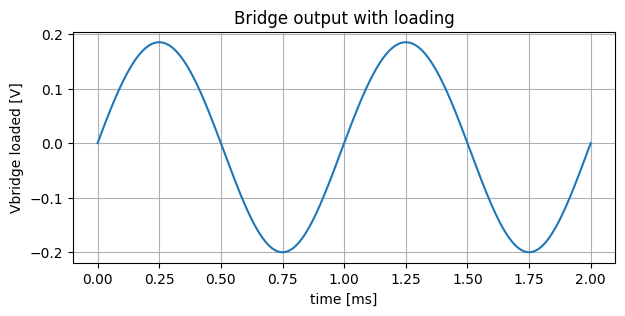

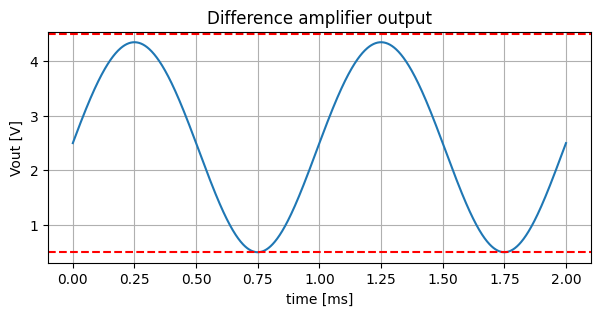

In [4]:
t=np.linspace(0,2e-3,1200)
delta=DeltaR_max*np.sin(2*np.pi*1000*t)
vb=vbridge_loaded(delta)
vout=Vref+G*vb

print(f'vbridge min={vb.min()} V')
print(f'vbridge max={vb.max()} V')
print(f'vout min={vout.min()} V')
print(f'vout max={vout.max()} V')

plt.figure(figsize=(7,3))
plt.plot(t*1e3,vb)
plt.xlabel('time [ms]')
plt.ylabel('Vbridge loaded [V]')
plt.title('Bridge output with loading')
plt.grid(True)
plt.show()

plt.figure(figsize=(7,3))
plt.plot(t*1e3,vout)
plt.axhline(0.5,color='r',linestyle='--')
plt.axhline(4.5,color='r',linestyle='--')
plt.xlabel('time [ms]')
plt.ylabel('Vout [V]')
plt.title('Difference amplifier output')
plt.grid(True)
plt.show()

From the LTspice operating point at $\Delta R=0$,

$$
I(VDD)=-0.0100251A.
$$

The negative sign is the LTspice source-current sign convention, so the current delivered by the supply is

$$
I_{supply}=10.0251mA.
$$

The total power from the supply is therefore

$$
P_{total}=5V\cdot 10.0251mA=50.1255mW.
$$

In [5]:
I_supply_ltspice=10.0251e-3
P_total=VDD*I_supply_ltspice

print(f'LTspice I_supply={I_supply_ltspice*1e3:.4f} mA')
print(f'LTspice P_total={P_total*1e3:.4f} mW')

LTspice I_supply=10.0251 mA
LTspice P_total=50.1255 mW


__d)__ An instrumentation amplifier can be used to realize a mucher higher input impedance than the difference amplifier. Construct the instrumentation amplifier shown in Fig. 1b to achieve a gain of $20dB$, and run a transient simulation with the Wheatstone bridge model to show that the signal amplitude is increased due to the absence of loading. Submit your schematic with all DC node voltages shown.

For the instrumentation amplifier, I set the second difference stage to gain 1:

$$
\frac{R_2}{R_1}=1.
$$

I used

$$
R_1=25k\Omega, \qquad R_2=25k\Omega.
$$

Then the first stage needs all the gain:

$$
A_{first}=1+\frac{R_{fp}+R_{fm}}{R_G}=10.
$$

One simple choice is

$$
R_{fp}=45k\Omega, \qquad R_{fm}=45k\Omega, \qquad R_G=10k\Omega.
$$

Then

$$
1+\frac{45k+45k}{10k}=10.
$$

The big advantage is that the bridge only sees the op amp input, so the input resistance is basically infinite instead of $50k\Omega$.

In [6]:
Rfp=45e3
Rfm=45e3
RG=10e3
R1_out=25e3
R2_out=25e3
G_first=1+(Rfp+Rfm)/RG
G_second=R2_out/R1_out
G_total=G_first*G_second

print(f'first stage gain={G_first}')
print(f'second stage gain={G_second}')
print(f'total gain={G_total}')
print(f'total gain dB={20*math.log10(G_total)} dB')

first stage gain=10.0
second stage gain=1.0
total gain=10.0
total gain dB=20.0 dB


To compare the loading effect, I used $\Delta R=38\Omega$ here. That is a little below the maximum, so both amplifier outputs stay in range. The instrumentation amp uses the open-circuit bridge voltage, while the difference amp uses the slightly loaded bridge voltage.

difference amp Vout pp=3.76792215250137 V
instrumentation amp Vout pp=3.8054918597830665 V
increase=1.009970935109887


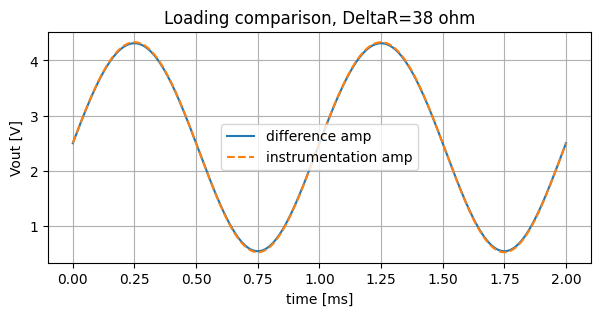

In [7]:
DR_compare=38

t=np.linspace(0,2e-3,1200)
delta=DR_compare*np.sin(2*np.pi*1000*t)
vb_open=vbridge_oc(delta)
vb_loaded=vbridge_loaded(delta)
vout_diff=Vref+G*vb_loaded
vout_inamp=Vref+G*vb_open

print(f'difference amp Vout pp={vout_diff.max()-vout_diff.min()} V')
print(f'instrumentation amp Vout pp={vout_inamp.max()-vout_inamp.min()} V')
print(f'increase={(vout_inamp.max()-vout_inamp.min())/(vout_diff.max()-vout_diff.min())}')

plt.figure(figsize=(7,3))
plt.plot(t*1e3,vout_diff,label='difference amp')
plt.plot(t*1e3,vout_inamp,label='instrumentation amp',linestyle='--')
plt.xlabel('time [ms]')
plt.ylabel('Vout [V]')
plt.title('Loading comparison, DeltaR=38 ohm')
plt.grid(True)
plt.legend()
plt.show()

The instrumentation amp output is a little larger, which is what I expected. The difference amp already met the 1% loading spec, so the increase is not huge, but it is visible when using the same bridge signal.